# 01. 데이터 이해 및 진단

원본 데이터의 구조, 변수 의미, 품질 문제와 처리 방법을 정리한다. 정제는 `src/data.py`, 15분 단위 변환과 피처 생성은 `src/features.py`를 사용한다.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.data import load_raw, clean
from src.features import to_long, build_features, feature_columns
from src.viz import setup_plot_style, heatmap, DOW_KR

setup_plot_style()
pd.set_option("display.max_columns", 50)
DATA = ROOT / C.DATA_PATH

## 1. 원본 데이터 개요

In [ ]:
raw = load_raw(DATA)
print("행, 열:", raw.drop(columns="_row").shape)
display(raw.drop(columns="_row").head())
display(raw.drop(columns="_row").describe().T.round(2))

행, 열: (6168, 18)


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


,count,mean,std,min,25%,50%,75%,max
날짜,6168.0,20210492.30,244.78,20210101.0,20210306.0,20210509.00,20210712.00,20210914.00
시간,6168.0,12.43,12.85,0.0,6.0,12.00,18.00,188.00
15분,6168.0,90.41,55.35,0.0,23.0,101.00,133.00,207.00
30분,6168.0,92.70,57.94,0.0,23.0,104.00,143.00,222.00
45분,6168.0,95.11,59.29,0.0,23.0,105.00,149.00,218.00
60분,6168.0,95.04,59.35,0.0,23.0,107.00,149.00,214.00
평균,6168.0,93.42,57.36,0.0,23.0,104.00,144.00,208.00
생산량,6168.0,467.34,857.57,0.0,0.0,45.00,637.25,9830.00
기온,6168.0,15.91,9.16,-12.0,9.6,17.40,23.30,33.40
풍속,6165.0,2.06,1.16,0.0,1.2,1.90,2.80,7.60


| 컬럼 | 의미 |
|---|---|
| `날짜`, `시간` | 1시간 단위, 하루 24행 |
| `15분`, `30분`, `45분`, `60분` | 각 15분 구간의 평균 수요전력(kW) |
| `평균` | 네 구간의 평균(반올림) = 시간당 사용량(kWh) |
| `생산량` | 시간별 생산량 |
| `기온`, `풍속`, `습도`, `강수량` | 기상 |
| `전기요금(계절)` | 월별 전기요금 상수 |
| `day`, `d`, `m` | 요일(월=1), 일, 월 |
| `공장인원` | 생산량 ÷ 전력 합계로 계산된 값 |
| `인건비` | 시간대 가중치(09~17시 1.0, 그 외 1.5) |

## 2. 시간 구조와 시간 오류 복원

In [ ]:
per_day = raw.groupby("날짜").size()
print("날짜별 행 수:", per_day.value_counts().to_dict())
print("시간 컬럼 범위:", raw["시간"].min(), "~", raw["시간"].max())
bad = raw[raw["시간"] > 23]
print(f"0~23 범위를 벗어난 행: {len(bad)}개, 날짜: {sorted(bad['날짜'].unique().tolist())}")
display(raw[raw["날짜"] == 20210713].drop(columns="_row").head(6))

날짜별 행 수: {24: 257}
시간 컬럼 범위: 0 ~ 188
0~23 범위를 벗어난 행: 48개, 날짜: [20210713, 20210715]


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
4632,20210713,70,70,69,69,69,69,0,25.1,2.0,98,0.0,191.6,2,13,7,0.0,1.5
4633,20210713,89,77,93,119,94,96,0,25.0,1.3,97,0.0,191.6,2,13,7,0.0,1.5
4634,20210713,90,117,110,114,107,112,0,24.9,1.5,96,0.0,191.6,2,13,7,0.0,1.5
4635,20210713,97,115,107,112,107,110,0,24.7,0.4,96,0.0,191.6,2,13,7,0.0,1.5
4636,20210713,107,106,112,101,106,106,0,24.5,1.4,96,0.0,191.6,2,13,7,0.0,1.5
4637,20210713,108,121,153,162,136,143,0,24.7,0.2,96,0.0,191.6,2,13,7,0.0,1.5


7/13, 7/15는 `시간` 컬럼에 0~23의 범위를 벗어나는 결과가 들어가 있다. 날짜별 24행이 유지되므로 행 순서로 시간을 복원한다. 시각은 구간 시작 기준(`15분` 컬럼 = 00:00~00:15 → 00:00)으로 표기한다.

In [ ]:
hourly, dq, groups = clean(raw)
long = to_long(hourly)
print("복원 행:", dq["hour_repaired"])
print("복원 후 결측 시각:", dq["missing_hours_after_repair"], "/ 중복 시각:", dq["duplicate_ts_after_repair"])
display(hourly[hourly["date"] == "2021-07-13"].head(6))

복원 행: {'rows': 48, 'dates': ['20210713', '20210715']}
복원 후 결측 시각: 0 / 중복 시각: 0


,ts,date,hour,dow,15분,30분,45분,60분,kw_hour_avg,prod,temp,humidity,wind,rain,labor_mult,tariff_season,hour_repaired,dup_group,dup_group_size,is_copy_day
4632,2021-07-13 00:00:00,2021-07-13,0,2,70,69,69,69,69,0,25.1,98,2.0,0.0,1.5,191.6,True,79,1,False
4633,2021-07-13 01:00:00,2021-07-13,1,2,77,93,119,94,96,0,25.0,97,1.3,0.0,1.5,191.6,True,79,1,False
4634,2021-07-13 02:00:00,2021-07-13,2,2,117,110,114,107,112,0,24.9,96,1.5,0.0,1.5,191.6,True,79,1,False
4635,2021-07-13 03:00:00,2021-07-13,3,2,115,107,112,107,110,0,24.7,96,0.4,0.0,1.5,191.6,True,79,1,False
4636,2021-07-13 04:00:00,2021-07-13,4,2,106,112,101,106,106,0,24.5,96,1.4,0.0,1.5,191.6,True,79,1,False
4637,2021-07-13 05:00:00,2021-07-13,5,2,121,153,162,136,143,0,24.7,96,0.2,0.0,1.5,191.6,True,79,1,False


## 3. 정합성 검증

In [ ]:
mean4 = raw[C.POWER_COLS].mean(axis=1)
diff = (raw["평균"] - mean4).round(2)
print("평균 − 네 구간 평균:", diff.value_counts().sort_index().to_dict())
print("day 컬럼 = 실제 요일(월=1):", dq["day_col_is_weekday_mon1_sun7"])

평균 − 네 구간 평균: {-0.25: 1500, 0.0: 1831, 0.25: 1419, 0.5: 1418}
day 컬럼 = 실제 요일(월=1): True


`평균`과 네 구간 평균의 차이는 반올림 범위(±0.5) 안에 있다.

## 4. 변수 의미 검증

### 4-1. 공장인원

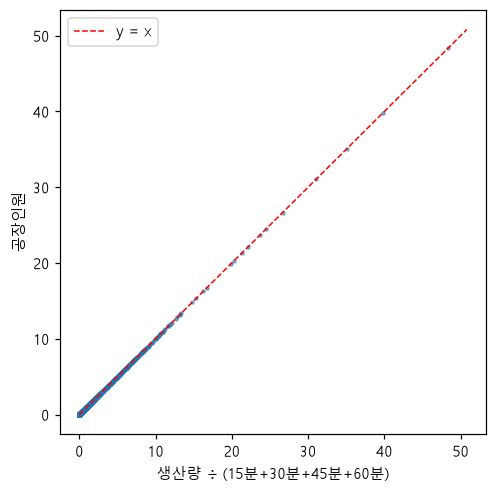

최대 오차: 4.944070042256499e-09
결측(0/0): 17


In [ ]:
s = raw[C.POWER_COLS].sum(axis=1)
ratio = raw["생산량"] / s.where(s > 0)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(ratio, raw["공장인원"], s=4, alpha=0.5)
lim = [0, np.nanmax(ratio) * 1.05]
ax.plot(lim, lim, "r--", lw=1, label="y = x")
ax.set_xlabel("생산량 ÷ (15분+30분+45분+60분)")
ax.set_ylabel("공장인원")
ax.legend()
plt.show()
print("최대 오차:", dq["leakage_factory_staff"]["max_abs_diff_vs_prod_over_power_sum"])
print("결측(0/0):", dq["leakage_factory_staff"]["nan_rows_all_0_div_0"])

`공장인원`은 타깃(전력)을 분모로 계산된 값이므로 피처에서 제외한다.

### 4-2. 인건비

규칙(09~17시 1.0, 그 외 1.5)의 예외: 18행, 날짜: [20210713, 20210715]


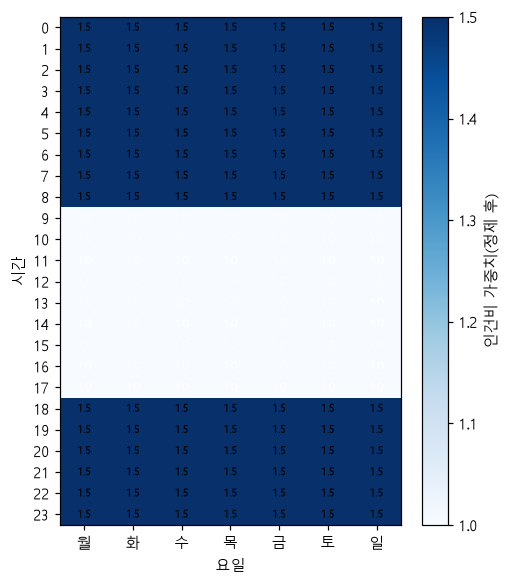

In [ ]:
rawh = raw.sort_values(["날짜", "_row"]).assign(hour=lambda d: d.groupby("날짜").cumcount())
rule = np.where(rawh["hour"].between(9, 17), 1.0, 1.5)
exc = rawh[rawh["인건비"] != rule]
print(f"규칙(09~17시 1.0, 그 외 1.5)의 예외: {len(exc)}행, 날짜: {sorted(exc['날짜'].unique().tolist())}")
lab = hourly.pivot_table(index="hour", columns="dow", values="labor_mult", aggfunc="mean").rename(columns=DOW_KR)
fig, ax = plt.subplots(figsize=(5, 6))
heatmap(lab, ax=ax, cmap="Blues", annotate=True, fmt="{:.1f}", cbar_label="인건비 가중치(정제 후)")
ax.set_xlabel("요일")
ax.set_ylabel("시간")
plt.show()

예외는 시간 오류가 있는 7/13, 7/15뿐이며, 오류 시간값(17 초과)으로 계산된 결과로 판단해 복원된 시간으로 재계산한다. 인건비는 시간대로 결정되므로 피처로 사용하지 않는다.

### 4-3. 전기요금(계절)

In [ ]:
display(raw.groupby("m")["전기요금(계절)"].agg(["min", "max", "nunique"]))

,min,max,nunique
m,,,
1,109.8,109.8,1
2,109.8,109.8,1
3,167.2,167.2,1
4,167.2,167.2,1
5,167.2,167.2,1
6,191.6,191.6,1
7,191.6,191.6,1
8,191.6,191.6,1
9,167.2,167.2,1


## 5. 결측과 전력 0 구간

결측 컬럼: {'풍속': 3, '강수량': 1, '공장인원': 17}
전력 0 구간(15분): {'n': 74, 'dates': ['2021-08-28', '2021-08-29', '2021-09-08']}


,min,max,count
date,,,
2021-08-28,2021-08-28 17:30:00,2021-08-28 23:45:00,26
2021-08-29,2021-08-29 00:00:00,2021-08-29 11:15:00,46
2021-09-08,2021-09-08 12:00:00,2021-09-08 12:15:00,2


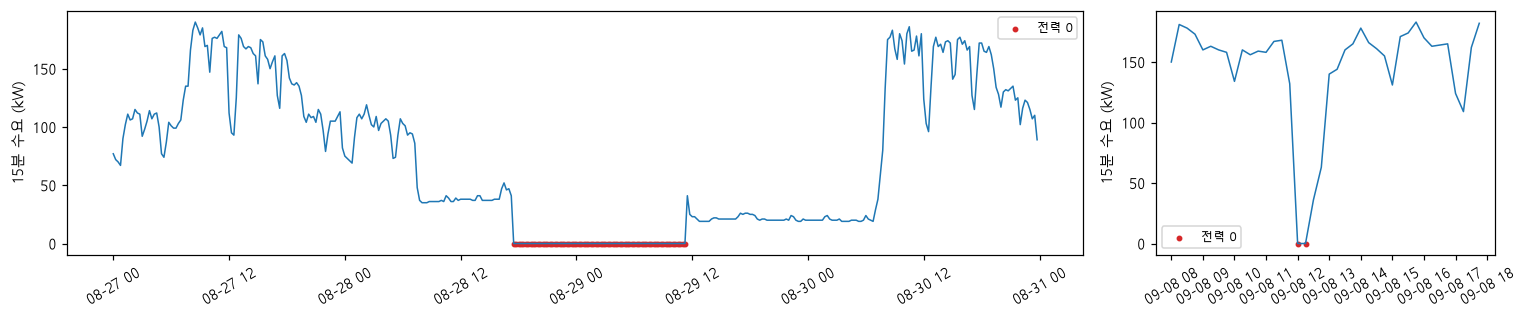

In [ ]:
print("결측 컬럼:", raw.isna().sum()[lambda x: x > 0].to_dict())
print("전력 0 구간(15분):", dq["zero_power_15min_slots"])
zero = long[long["kw"] == 0]
display(zero.groupby("date")["ts"].agg(["min", "max", "count"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 3), gridspec_kw={"width_ratios": [3, 1]})
for ax, (a, b) in zip(axes, [("2021-08-27", "2021-08-31"), ("2021-09-08 08:00", "2021-09-08 18:00")]):
    w = long[(long["ts"] >= a) & (long["ts"] < b)]
    ax.plot(w["ts"], w["kw"], lw=1)
    z = w[w["kw"] == 0]
    ax.scatter(z["ts"], z["kw"], s=8, color="tab:red", label="전력 0")
    ax.set_ylabel("15분 수요 (kW)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.show()

기상 결측은 시간순 선형보간한다. `공장인원` 결측은 생산량과 전력이 모두 0인 0/0이다. 전력 0 구간(8/28 17:30~8/29 11:15, 9/8 12:00~12:15)은 정전으로 추정되며 별도 처리 없이 그대로 사용한다.

## 6. 증강 복제일

하루 96개 전력값이 완전히 같은 날을 같은 복제그룹으로 묶는다.

{'n_days': 257, 'n_unique_profiles': 142, 'n_days_in_duplicate_groups': 160, 'n_copy_days_excluding_first': 115}


,dup_group,size,dates
0,4,15,"2021-01-05, 2021-01-06, 2021-01-12, 2021-01-13..."
1,1,7,"2021-01-02, 2021-02-05, 2021-03-06, 2021-03-13..."
2,26,6,"2021-02-06, 2021-02-12, 2021-02-13, 2021-02-20..."
3,45,6,"2021-04-12, 2021-04-13, 2021-04-14, 2021-04-15..."
4,47,5,"2021-04-21, 2021-04-22, 2021-04-23, 2021-04-30..."
5,27,5,"2021-02-07, 2021-02-14, 2021-02-21, 2021-02-28..."
6,14,4,"2021-01-18, 2021-02-18, 2021-03-18, 2021-06-18"
7,11,4,"2021-01-15, 2021-02-15, 2021-03-15, 2021-06-15"


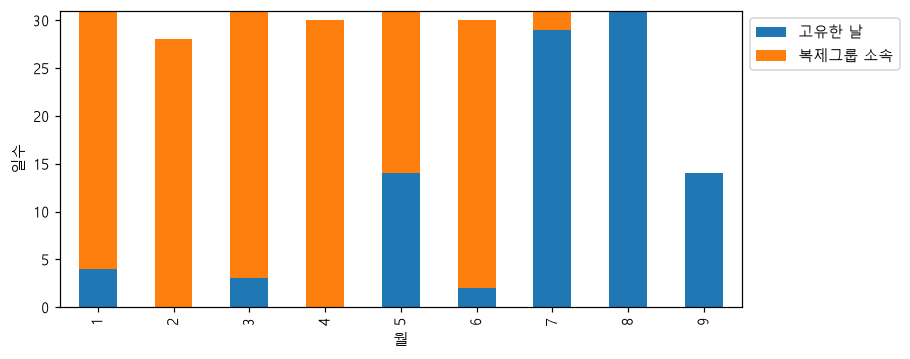

In [ ]:
print({k: v for k, v in dq["duplicate_days"].items() if k != "days_in_duplicate_groups_by_month"})
display(groups.head(8))

d = hourly.groupby("date").agg(size=("dup_group_size", "first"))
by_m = pd.DataFrame({
    "고유한 날": (d["size"] == 1).groupby(d.index.month).sum(),
    "복제그룹 소속": (d["size"] > 1).groupby(d.index.month).sum(),
})
ax = by_m.plot(kind="bar", stacked=True, figsize=(8, 3.5))
ax.set_xlabel("월")
ax.set_ylabel("일수")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

가동일 패턴(일평균 50kW 초과)을 가진 가장 큰 복제그룹의 프로파일은 완전히 겹치지만, 해당 날짜의 요일·기상·생산량은 서로 다르다.

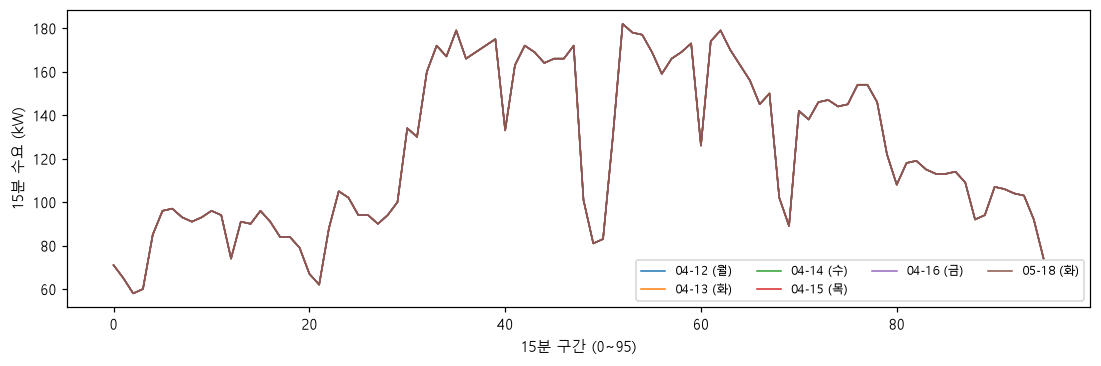

,요일,생산량_합계,평균기온
date,,,
2021-04-12,월,16126,12.7
2021-04-13,화,20850,17.4
2021-04-14,수,17711,10.6
2021-04-15,목,16202,11.2
2021-04-16,금,19753,13.9
2021-05-18,화,23411,15.9


In [ ]:
group_kw = long.groupby("dup_group")["kw"].mean()
g = groups[groups["dup_group"].map(group_kw) > 50].iloc[0]
dates = pd.to_datetime(g["dates"].split(", "))
fig, ax = plt.subplots(figsize=(12, 3.5))
for dt in dates:
    s = long[long["date"] == dt]
    ax.plot(s["slot"], s["kw"], lw=1, label=f"{dt:%m-%d} ({DOW_KR[dt.dayofweek + 1]})")
ax.set_xlabel("15분 구간 (0~95)")
ax.set_ylabel("15분 수요 (kW)")
ax.legend(ncol=4, fontsize=8)
plt.show()
ctx = hourly[hourly["date"].isin(dates)].groupby("date").agg(
    요일=("dow", lambda x: DOW_KR[x.iloc[0]]), 생산량_합계=("prod", "sum"), 평균기온=("temp", "mean"))
display(ctx.round(1))

일평균 50kW 초과를 가동으로 보고, 생산량 유무 및 달력(평일·비공휴일, 토요일 제외)과의 불일치율을 날짜 유형별로 비교한다.

In [ ]:
day = (long.groupby("date")
       .agg(kw=("kw", "mean"), prod=("prod", "sum"), dow=("dow", "first"),
            is_copy=("is_copy_day", "first"), size=("dup_group_size", "first")))
day["prod"] = day["prod"] / 4
hol = pd.to_datetime(C.HOLIDAYS)
on_power = day["kw"] > 50
on_cal = (day["dow"] <= 5) & ~day.index.isin(hol)
day["유형"] = np.select([day["size"] == 1, day["is_copy"]], ["고유한 날", "복제본(2번째 이후)"], "복제그룹 첫 등장일")
day["생산량과 불일치"] = (on_power != (day["prod"] > 0)).astype(float)
day["달력과 불일치"] = (on_power != on_cal).astype(float).where(day["dow"] != 6)
display(day.groupby("유형").agg(일수=("kw", "size"), 생산량과_불일치율=("생산량과 불일치", "mean"),
                              달력과_불일치율=("달력과 불일치", "mean")).round(3))

,일수,생산량과_불일치율,달력과_불일치율
유형,,,
고유한 날,97,0.186,0.122
복제그룹 첫 등장일,45,0.133,0.105
복제본(2번째 이후),115,0.157,0.170


불일치는 복제본 외의 날에도 나타난다. 복제일로 인한 평가 누수는 검증 단계의 복제그룹 제거(purge)와 원본일 채점으로 방지한다.

## 7. 전력 사용 패턴

복제본을 제외한 날로 집계한다.

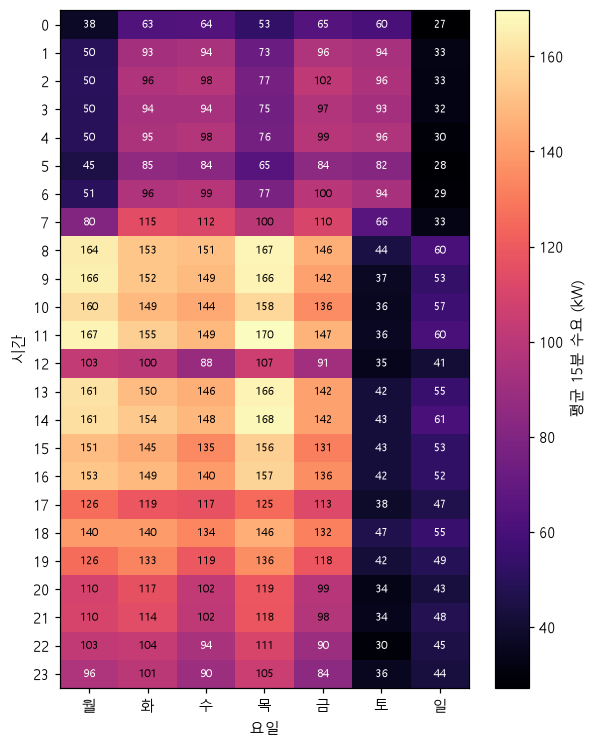

In [ ]:
ok = long[~long["is_copy_day"]]
hm = ok.pivot_table(index="hour", columns="dow", values="kw", aggfunc="mean").rename(columns=DOW_KR)
fig, ax = plt.subplots(figsize=(6, 8))
heatmap(hm, ax=ax, cmap="magma", annotate=True, cbar_label="평균 15분 수요 (kW)")
ax.set_xlabel("요일")
ax.set_ylabel("시간")
plt.show()

평일 주간(08~19시) 가동, 12시 점심 감소, 월요일 밤~토요일 오전 야간 가동, 일요일 대기부하 구조가 나타난다.

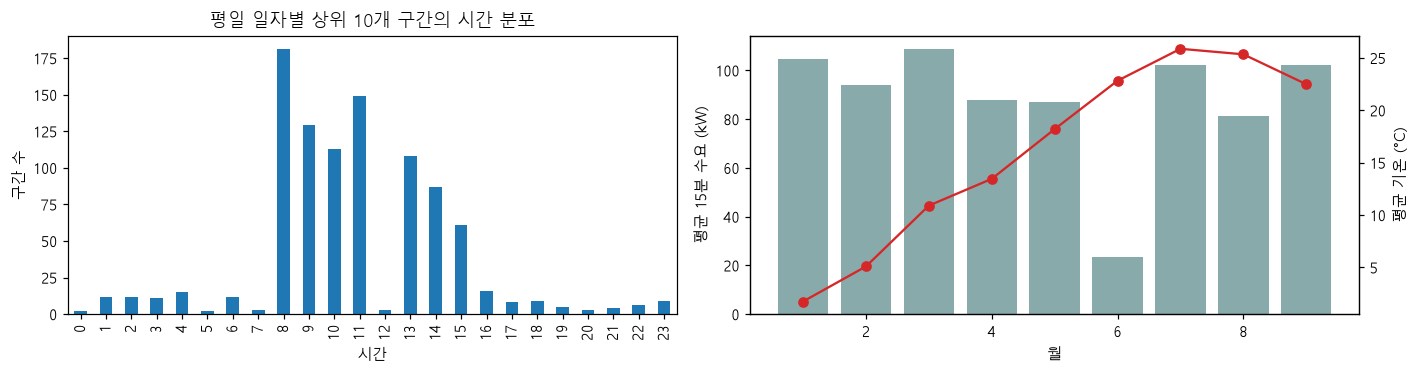

In [ ]:
top = (ok.sort_values("kw", ascending=False, kind="stable")
         .groupby("date").head(C.PEAK_TOP_K))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
top[top["dow"] <= 5]["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_xlabel("시간")
axes[0].set_ylabel("구간 수")
axes[0].set_title(f"평일 일자별 상위 {C.PEAK_TOP_K}개 구간의 시간 분포")
mon = ok.groupby(ok["ts"].dt.month).agg(kw=("kw", "mean"), temp=("temp", "mean"))
axes[1].bar(mon.index, mon["kw"], color="#8aa")
axes[1].set_xlabel("월")
axes[1].set_ylabel("평균 15분 수요 (kW)")
ax2 = axes[1].twinx()
ax2.plot(mon.index, mon["temp"], "o-", color="tab:red")
ax2.set_ylabel("평균 기온 (°C)")
plt.tight_layout()
plt.show()

## 8. 15분 변환과 피처

D일 00:00 시점에 D일 96개 구간을 예측하며, 피처는 해당 시점에 확정된 정보만 사용한다. 예시는 2021-08-30(월) 08:15 구간이다.

In [ ]:
feat = build_features(long)
cols = feature_columns()
print(f"{len(feat):,}행(첫 7일 제외), 피처 {len(cols)}개(7d) / {len(feature_columns(lookback='1d'))}개(1d)")
example = feat[feat["ts"] == "2021-08-30 08:15"]
display(example[["ts", "kw", *cols]].T.rename(columns=lambda _: "값"))

24,000행(첫 7일 제외), 피처 15개(7d) / 13개(1d)


,값
ts,2021-08-30 08:15:00
kw,175.0
hour,8
quarter,1
slot,33
dow,1
is_holiday,0
is_off_day,0
prev_is_off_day,1
is_startup,1


## 9. 진단 요약

| 항목 | 근거 | 처리 |
|---|---|---|
| 7/13, 7/15 `시간` 오류 | 날짜별 24행, 복원 후 결측·중복 시각 0 | 행 순서로 복원 |
| 같은 날의 `인건비` 오류 | 나머지 행에서 시간대 규칙 예외 없음 | 복원된 시간으로 재계산 |
| `공장인원` | 생산량 ÷ 전력 합계와 일치 | 제외(누수) |
| `인건비`, `전기요금(계절)` | 시간대·월로 결정 | 피처 제외, 비용 계산용 |
| 기상 결측 4개 | | 선형보간 |
| 전력 0 구간 74개 | 8/28~29, 9/8 | 별도 처리 없음 |
| 증강 복제일 160일 | 96개 값 해시 일치, 1~6월 집중 | 검증 시 purge, 원본일 채점 |


## 참고사항

LSTM은 시계열 데이터의 예측 성능을 높이기 위해 시간 정보를 주기적인 특성으로 표현하여 입력한다. 시간과 요일 등의 정보를 `sin`·`cos` 형태로 변환해 하루 및 주간 주기를 모델이 학습할 수 있도록 했으며, 예측 시점에 미리 알 수 있는 미래의 시간 정보도 LSTM 디코더의 피처로 다시 활용했다.